In [1]:
from datasets import load_dataset
import os

/Users/lusine/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/lusine/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset("clip-benchmark/wds_vtab-caltech101", split="test")

In [3]:
print(ds[0].keys())

dict_keys(['__key__', '__url__', 'cls', 'webp'])


In [4]:
img_key = "webp" if "webp" in ds[0] else "jpg"

In [5]:
out_dir = "my_photos"
os.makedirs(out_dir, exist_ok=True)

In [6]:
import random
random.seed(0)
labels_all = ds["cls"]
unique_labels = sorted(set(labels_all))
chosen_classes = random.sample(unique_labels, 12)

count = 0
per_class_budget = 15
seen_per_class = {c: 0 for c in chosen_classes}

for i, ex in enumerate(ds):
    c = ex["cls"]
    if c in chosen_classes and seen_per_class[c] < per_class_budget:
        img = ex[img_key]
        # filename now encodes the true class label first (e.g. class017_003.jpg)
        # so it can be recovered later for ARI/AMI, and sorts consistently
        fname = f"class{c:03d}_{seen_per_class[c]:03d}.jpg"
        img.convert("RGB").save(os.path.join(out_dir, fname))
        seen_per_class[c] += 1
        count += 1
    if count >= 180:
        break

print(f"Saved {count} images to {out_dir}/")


Saved 153 images to my_photos/


In [7]:
from PIL import Image
import numpy as np

In [8]:
img = Image.open("my_photos/100_8.jpg").convert("RGB")

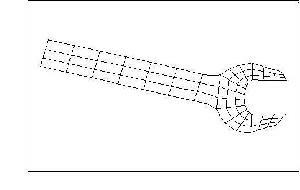

In [9]:
img

In [10]:
img.size

(300, 190)

In [11]:
img = img.resize((64, 64))

In [12]:
img_array = np.array(img)

In [13]:
img_vector = img_array.reshape(-1)

In [14]:
img_vector.shape

(12288,)

In [15]:
folder = "my_photos"
filenames = sorted(f for f in os.listdir(folder) if f.lower().endswith(".jpg"))

raw_vectors = []
for fname in filenames:
    img = Image.open(os.path.join(folder, fname)).convert("RGB")
    img = img.resize((64, 64))
    arr = np.array(img) / 255.0
    raw_vectors.append(arr.flatten())

raw_vectors = np.array(raw_vectors)
print(raw_vectors.shape)


(306, 12288)


In [16]:
# true labels, extracted from filenames
# filenames look like "class017_003.jpg" -> label 17
true_labels = [int(f.split("_")[0].replace("class", "")) for f in filenames]

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [18]:
X = raw_vectors.astype(np.float32) 

In [19]:
inertias = []
sil_scores = []
k_range = range(5, 15)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels_k))

/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:2

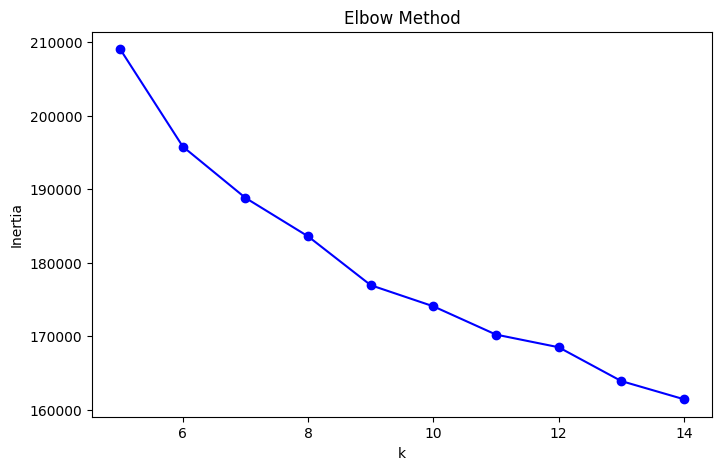

In [20]:
# Elbow plot
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'b-o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

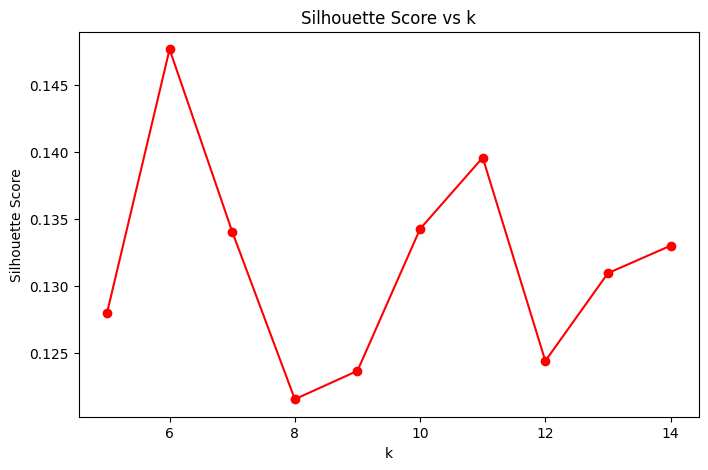

In [21]:
# Silhouette plot
plt.figure(figsize=(8, 5))
plt.plot(k_range, sil_scores, 'r-o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.show()

k=7 was chosen because the elbow curve flattens around k=7-8, and the silhouette score peaks near k=6-7. The two methods agree at k=7.

In [22]:
km_raw_final = KMeans(n_clusters=7, random_state=42, n_init=10)
raw_labels = km_raw_final.fit_predict(X)


/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [23]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

ari_raw = adjusted_rand_score(true_labels, raw_labels)
ami_raw = adjusted_mutual_info_score(true_labels, raw_labels)

print("Raw pixels  -> ARI:", round(ari_raw, 3), " AMI:", round(ami_raw, 3))


Raw pixels  -> ARI: 0.161  AMI: 0.312


k=6 was chosen mainly because of the silhouette score as it has one clear, sharp peak at k=6, noticeably higher than any other value. The elbow plot doesn't have one obvious bend, but the curve does start to flatten out around k=7-8, which is close enough to k=6 that it doesn't really disagree with the silhouette result.

In [24]:
km_raw_final = KMeans(n_clusters=6, random_state=42, n_init=10)
raw_labels = km_raw_final.fit_predict(X)

/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [25]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

ARI(Adjusted Rand Index) measures how similar your clustering is to the true labels.
AMI(Adjusted Mutual Information) measures how much information your clustering shares with the true labels.

In [26]:
ari_raw = adjusted_rand_score(true_labels, raw_labels)
ami_raw = adjusted_mutual_info_score(true_labels, raw_labels)

print("Raw pixels  -> ARI:", round(ari_raw, 3), " AMI:", round(ami_raw, 3))

Raw pixels  -> ARI: 0.122  AMI: 0.262


Raw pixels gave low clustering performance, so they did not separate the image classes well.

Now with embeddings

In [27]:
embeddings_data = np.load("my_photos_clip.npz")
embeddings = embeddings_data["embeddings"]
print(f"Loaded embeddings: {embeddings.shape}")

Loaded embeddings: (153, 512)


In [28]:
out_dir = "my_photos"
image_files = sorted([f for f in os.listdir(out_dir) if f.endswith('.jpg')])
true_labels = np.array([int(f.split('_')[0].replace('class', '')) for f in image_files])

print(f"Total images: {len(image_files)}")
print(f"Unique classes: {sorted(np.unique(true_labels))}")
print(f"Distribution: {np.bincount(true_labels)}")

Total images: 306
Unique classes: [np.int64(5), np.int64(33), np.int64(38), np.int64(45), np.int64(49), np.int64(51), np.int64(53), np.int64(61), np.int64(62), np.int64(65), np.int64(97), np.int64(100)]
Distribution: [ 0  0  0  0  0 30  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 30  0  0  0  0 30  0  0  0  0  0  0 30  0  0
  0 30  0  2  0 30  0  0  0  0  0  0  0 26 20  0  0 30  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0 30  0  0 18]


In [29]:
k_range = range(5, 16)
silhouette_scores = []
inertia_values = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(embeddings)
    sil_score = silhouette_score(embeddings, labels)
    silhouette_scores.append(sil_score)
    inertia_values.append(km.inertia_)


/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:2

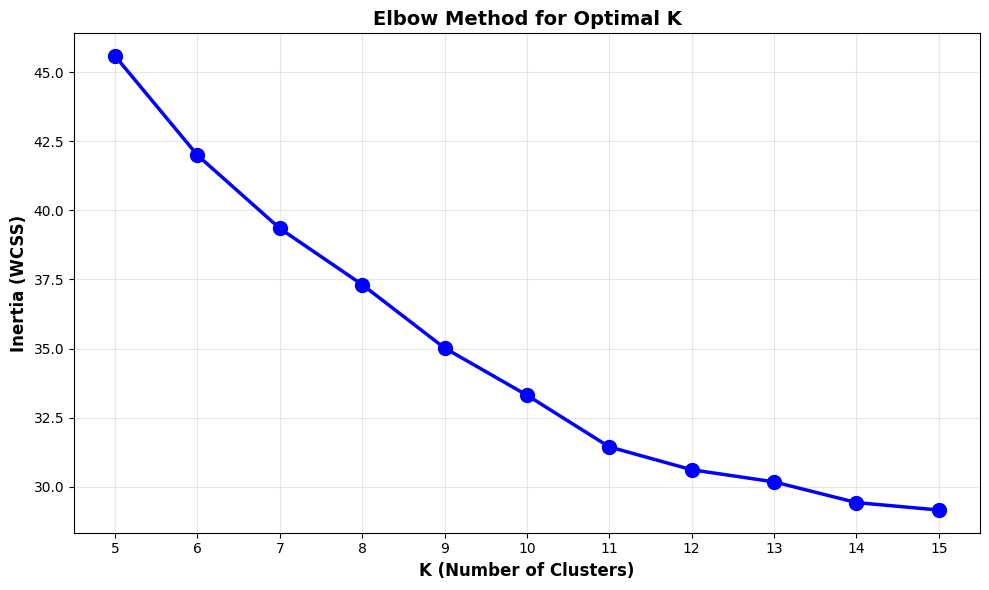

In [30]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, 'b-o', linewidth=2.5, markersize=10)
plt.xlabel("K (Number of Clusters)", fontsize=12, fontweight='bold')
plt.ylabel("Inertia (WCSS)", fontsize=12, fontweight='bold')
plt.title("Elbow Method for Optimal K", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.tight_layout()
plt.show()

/var/folders/fv/yzgrhj916vg8plv0w2gwcgkm0000gn/T/ipykernel_69117/632471532.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


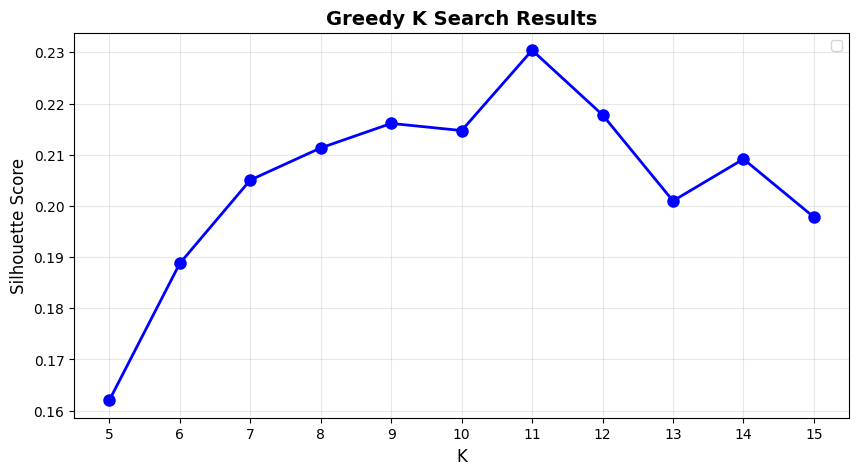

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
plt.xlabel('K', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Greedy K Search Results', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.show()

K=11 was selected because it has the maximum silhouette score, indicating the best cluster separation. This choice is validated by the elbow method, where K=11 marks the point beyond which increasing K produces minimal changes in inertia, suggesting no significant improvement in clustering quality.

In [32]:
best_k = k_range[np.argmax(silhouette_scores)]

In [33]:
km_embed = KMeans(n_clusters=best_k, random_state=42, n_init=10)
predicted_labels_embed = km_embed.fit_predict(embeddings)
print(f"✓ Clustering done with K={best_k}")
print(f"  Cluster sizes: {np.bincount(predicted_labels_embed)}")

✓ Clustering done with K=11
  Cluster sizes: [15 15  9 12 15 15 15 15 12 15 15]


/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [34]:
# If there are more images than embeddings, use only the first N images
image_files_aligned = image_files[:embeddings.shape[0]]
true_labels = np.array([int(f.split('_')[0].replace('class', '')) for f in image_files_aligned])

In [35]:
ari_embed = adjusted_rand_score(true_labels, predicted_labels_embed)
ami_embed = adjusted_mutual_info_score(true_labels, predicted_labels_embed)

print("CLIP Embeddings  -> ARI:", round(ari_embed, 3), "  AMI:", round(ami_embed, 3))

CLIP Embeddings  -> ARI: 0.972   AMI: 0.972


CLIP embeddings gave  high clustering performance, separating the image classes very well.

Embedding visualization

In [36]:
from sklearn.manifold import TSNE

In [37]:
tsne = TSNE(n_components=2, random_state=42)
coords_2d = tsne.fit_transform(embeddings)

/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A.T @ Q)


In [47]:
from photo_map import make_photo_map
from pathlib import Path

In [49]:
image_bytes = [
    (Path("my_photos") / f).read_bytes()
    for f in image_files_aligned
]

make_photo_map(
    xy=coords_2d,
    jpegs=image_bytes,
    groups=predicted_labels_embed,
    title="My Clusters"
)

PosixPath('photo_map.html')

PCA

In [50]:
from sklearn.decomposition import PCA

In [52]:
pca = PCA(n_components=2)

pca_coords = pca.fit_transform(embeddings)

/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A.T @ Q)


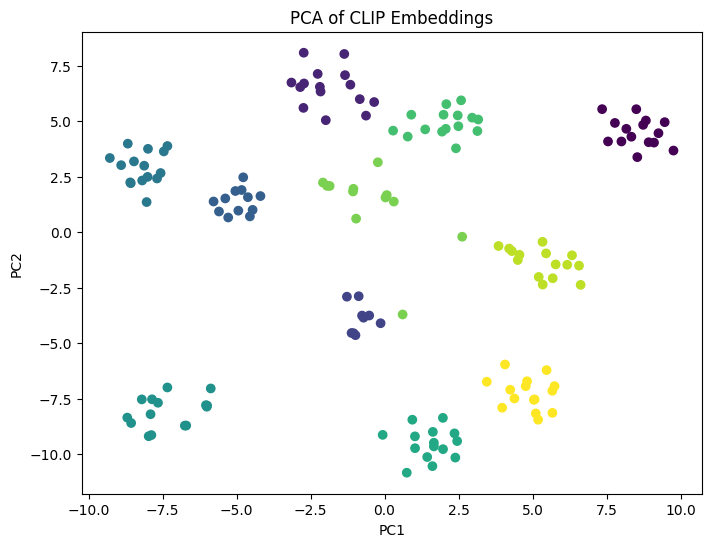

In [53]:
plt.figure(figsize=(8, 6))

plt.scatter(
    coords_2d[:, 0],
    coords_2d[:, 1],
    c=predicted_labels_embed
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of CLIP Embeddings")
plt.show()